In [7]:
import re
import nltk
import emoji
import pickle
import stanza
import hashlib
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from bs4 import BeautifulSoup as beau
from sklearn.metrics import confusion_matrix
from sklearn.naive_bayes import MultinomialNB as mnb
from sklearn.model_selection import train_test_split as tts
from sklearn.feature_extraction.text import TfidfVectorizer as TFIDFV
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction import DictVectorizer
from sklearn.metrics import accuracy_score

In [ ]:
import dask
from dask.distributed import Client, LocalCluster
client = Client(processes=True, n_workers=4, threads_per_worker=20)

## set-up

In [ ]:
manual = pickle.load(open('fics_df_manual.pkl', 'rb'))

In [ ]:
#pickle.dump(manual, open('manual_two.pkl', 'wb'))

In [ ]:
scraped = pickle.load(open('scraped_fics_dataframe.pkl', 'rb'))

In [ ]:
manual['work'] = manual.work.map(lambda x : [beau(y).text for y in x][0])
manual = manual[['L1', 'work']]
scraped = scraped[['L1', 'work']]

In [ ]:
all_df = pd.concat([manual, scraped], ignore_index=True)

In [ ]:
def get_punct(s):
    remove_n = re.compile(r'\s*\n+', re.S)
    s = re.sub(remove_n, ' ', s)
    return [x for x in s if not x.isalpha() and not x.isdigit()]

In [ ]:
all_df_trunc = all_df[['L1', 'work']]
all_df_trunc['work'] = all_df_trunc.work.map(lambda x : ''.join(x))
all_df_trunc['punct'] = all_df_trunc.work.map(lambda x : get_punct(x))

In [ ]:
ls = []
for p in all_df_trunc['punct']:
    ls.append(list(set([q for q in p])))

In [ ]:
lst = []
for p in ls:
    if type(p) is list:
        for q in p:
            lst.append(q)

In [ ]:
all_df_trunc['work'] = all_df_trunc.work.map(lambda x : (re.sub(r'\n', ' ', x)))

In [ ]:
config = {
    'processors':'tokenize,mwt,pos,lemma',
    'lang':'en',
    'download_method':None
}
stnz = stanza.Pipeline(**config)

In [ ]:
#testing = stnz('This is a sentence that has never been typed before (at least in this file).')

In [ ]:
#print(*[f'word: {word.text}\tupos: {word.upos}\txpos: {word.xpos}\tfeats: {word.feats if word.feats else "_"}' for sent in testing.sentences for word in sent.words], sep='\n')

In [ ]:
#larger_test = stnz(all_df_trunc['work'][0])
#[(word.text, word.upos, word.feats if word.feats else "_") for sent in larger_test.sentences for word in sent.words]

In [ ]:
# str: [word.feats for sent in larger_test.sentences for word in sent.words][0]
all_df_trunc['toks'] = all_df_trunc.work.map(lambda x : [word.text for sent in stnz(x).sentences for word in sent.words])

In [ ]:
# pickle.dump(all_df_trunc, open('fics_all_toks.pkl', 'wb'))
# (reran after next two cells)

In [ ]:

all_df_trunc['word_feats'] = all_df_trunc.work.map(lambda x : [word.feats for sent in stnz(x).sentences for word in sent.words])

In [ ]:
split = all_df_trunc[all_df_trunc['L1']=='Chinese/Filipino']
split2 = all_df_trunc[all_df_trunc['L1']=='Russian/Italian']
split = pd.concat([split, split], ignore_index=True)
split2 = pd.concat([split2, split2], ignore_index=True)
split['L1'][0] = 'Chinese'
split['L1'][1] ='Filipino'
split2['L1'][0] =  'Russian'
split2['L1'][1] = 'Italian'

In [ ]:
#all_df_trunc[all_df_trunc['L1']=='Chinese/Filipino'] ## 127
#all_df_trunc[all_df_trunc['L1']=='Russian/Italian'] ## 214
all_df_trunc = all_df_trunc.drop(index=[127,214]).reset_index(drop=True)
all_df_trunc = pd.concat([all_df_trunc, split, split2], ignore_index=True)

In [ ]:
#pickle.dump(all_df_trunc, open('all_df_dist.pkl', 'wb'))

In [28]:
all_df = pickle.load(open('all_df_dist.pkl', 'rb'))

## distribution time!!!

### testing stuff

In [ ]:
props = dict(all_df_trunc['L1'].value_counts())
all_df_trunc['bigrams'] = all_df_trunc.toks.map(lambda x : list(nltk.bigrams(x)))
all_df_trunc['feat_bigrams'] = all_df_trunc.word_feats.map(lambda x : list(nltk.bigrams(x)))
all_df_trunc['trigrams'] = all_df_trunc.toks.map(lambda x : list(nltk.ngrams(x, 3)))
all_df_trunc['feat_trigrams'] = all_df_trunc.word_feats.map(lambda x : list(nltk.ngrams(x, 3)))

In [ ]:
all_df_trunc['toks_2grams_fd'] = all_df_trunc.bigrams.map(lambda x : nltk.FreqDist(x))
all_df_trunc['feats_2grams_fd'] = all_df_trunc.feat_bigrams.map(lambda x : nltk.FreqDist(x))
all_df_trunc['toks_3grams_fd'] = all_df_trunc.trigrams.map(lambda x : nltk.FreqDist(x))
all_df_trunc['feats_3grams_fd'] = all_df_trunc.feat_trigrams.map(lambda x : nltk.FreqDist(x))
all_df_trunc['toks_2grams_cfd'] = all_df_trunc.bigrams.map(lambda x : nltk.ConditionalFreqDist(x))
all_df_trunc['feats_2grams_cfd'] = all_df_trunc.feat_bigrams.map(lambda x : nltk.ConditionalFreqDist(x))

In [ ]:
#all_df_trunc['toks_3grams_cfd'] = all_df_trunc.trigrams.map(lambda x : nltk.ConditionalFreqDist(x))
#all_df_trunc['feats_3grams_cfd'] = all_df_trunc.feat_trigrams.map(lambda x : nltk.ConditionalFreqDist(x))

In [12]:
# consideration to search without top XYZ across all

def flatten(a):
    ls = []
    for x in a:
        if type(x) is list:
            for y in x:
                ls.append(y.lower())
        else:
            return 'PRANKED'
    return ls

In [ ]:
all_toks = flatten(all_df_trunc['toks'])

In [ ]:
toks_alpha_only = [x for x in all_toks if x.isalpha()]
# got rid of contractions ^~^

In [ ]:
toks_fd = nltk.FreqDist(all_toks)
alpha_toks_fd = nltk.FreqDist(toks_alpha_only)

In [ ]:
all_df_trunc.sample()

In [ ]:
df = all_df_trunc.sample(frac=1) # shuffling!

In [ ]:
df['work'][298] # somehow something italian made it here?

In [ ]:
df = df.drop(index=[298])
df = df.reset_index(drop=True)

In [ ]:
#pickle.dump(df, open('df_df.pkl', 'wb'))

### testing more stuff

### failure

In [81]:
# 1. Get all unique morph features from the whole dataset
def get_all_morph_feats(df):
    all_feats = set()
    for feats_list in df['word_feats']:
        for feat_str in feats_list:
            if isinstance(feat_str, str):
                all_feats.update(feat_str.split('|'))
    return sorted(all_feats)

# 2. Feature extraction function using full morph feature set
def extract_features(row, all_feats_list):
    features = {}

    # Basic features
    features['token_count'] = len(row['toks'])
    features['unique_feats'] = len(set(row['word_feats']))

    # Frequency sums
    features['feat2gram_freq_sum'] = sum(row['feats_2grams_fd'].values()) if isinstance(row['feats_2grams_fd'], dict) else 0
    features['feat3gram_freq_sum'] = sum(row['feats_3grams_fd'].values()) if isinstance(row['feats_3grams_fd'], dict) else 0

    # Morphological features as binary flags
    row_feats = set()
    for feat_str in row['word_feats']:
        if isinstance(feat_str, str):
            row_feats.update(feat_str.split('|'))

    for feat in all_feats_list:
        features[f'has_{feat}'] = int(feat in row_feats)

    return features

# 3. Split the data
train_df, test_df = train_test_split(all_df, test_size=0.2, random_state=42)

# 4. Extract the full feature set from the combined dataset
all_feats_list = get_all_morph_feats(all_df)

# 5. Apply feature extraction
X_train_dicts = train_df.apply(lambda row: extract_features(row, all_feats_list), axis=1)
X_test_dicts = test_df.apply(lambda row: extract_features(row, all_feats_list), axis=1)
y_train = train_df['L1']
y_test = test_df['L1']

# 6. Vectorize features
vec = DictVectorizer(sparse=False)
X_train = vec.fit_transform(X_train_dicts)
X_test = vec.transform(X_test_dicts)

# 7. Train and evaluate Naive Bayes classifier
model = mnb()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# 8. Evaluate accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.046875


Accuracy: 0.046875


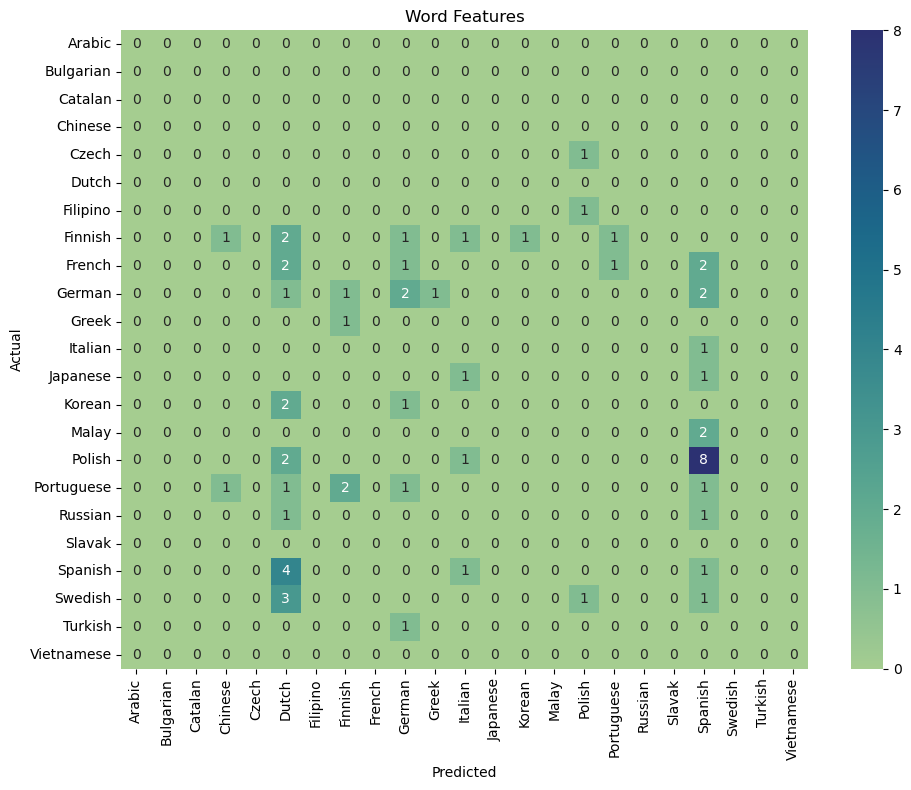

In [83]:
# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

# Plot it
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='crest',
            xticklabels=model.classes_,
            yticklabels=model.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Word Features')
plt.tight_layout()
plt.show()

### hope

In [32]:
all_feats_list
types = set([re.search(r'.*(?==)', x)[0] for x in all_feats_list])
vars = set([re.search(r'(?<==).*', x)[0] for x in all_feats_list])

In [33]:
def feats_dict(x):
    d = {}
    for y in x:
        try:
            for z in y.split('|'):
                d.update({(re.search(r'.*(?==)', z)[0]):(re.search(r'(?<==).*', z)[0])})
        except:
            continue
    return d

In [89]:
df_punct = all_df[['L1', 'punct']]
punct_set = list(set([p for l in df_punct['punct'] for p in l]))

In [90]:
df_feats = all_df[['L1', 'word_feats']]
df_feats['feats_dict'] = df_feats.word_feats.map(lambda x : feats_dict(x))

C:\Users\jbean\AppData\Local\Temp\ipykernel_29424\388389881.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_feats['feats_dict'] = df_feats.word_feats.map(lambda x : feats_dict(x))


In [91]:
punct_list = []
def is_emoji(s):
    return any(char in emoji.EMOJI_DATA for char in s)
for x in punct_set:
    if (not is_emoji(x)):
        punct_list.append(x)
quot = ['"', "'", '“', '”', '‘', '’', '«', '»', '„', '‚', ':', '…', '¡', '¿']
for punct in quot:
    df_punct[f'quot_{punct}'] = df_punct['punct'].apply(lambda x: 1 if punct in x else 0)

C:\Users\jbean\AppData\Local\Temp\ipykernel_29424\2065837369.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_punct[f'quot_{punct}'] = df_punct['punct'].apply(lambda x: 1 if punct in x else 0)
C:\Users\jbean\AppData\Local\Temp\ipykernel_29424\2065837369.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_punct[f'quot_{punct}'] = df_punct['punct'].apply(lambda x: 1 if punct in x else 0)
C:\Users\jbean\AppData\Local\Temp\ipykernel_29424\2065837369.py:9: SettingWithCopyWarning: 
A value is trying to b

In [ ]:
#pickle.dump(df_punct, open('df_punct.pkl', 'wb'))
#pickle.dump(df_feats, open('df_feats.pkl', 'wb'))

In [37]:
df_feats

,L1,word_feats,feats_dict
0,Portuguese,"[Definite=Def|PronType=Art, Degree=Pos, Number...","{'Definite': 'Def', 'PronType': 'Art', 'Degree..."
1,Portuguese,"[Number=Sing, Mood=Ind|Number=Sing|Person=3|Te...","{'Number': 'Plur', 'Mood': 'Ind', 'Person': '3..."
2,Portuguese,"[Number=Sing, Mood=Ind|Number=Sing|Person=3|Te...","{'Number': 'Plur', 'Mood': 'Imp', 'Person': '3..."
3,Portuguese,"[Number=Sing, Mood=Ind|Number=Sing|Person=3|Te...","{'Number': 'Plur', 'Mood': 'Imp', 'Person': '1..."
4,Korean,"[Definite=Def|PronType=Art, Number=Plur, Mood=...","{'Definite': 'Def', 'PronType': 'Dem', 'Number..."
...,...,...,...
312,Turkish,"[Number=Sing, Mood=Ind|Number=Sing|Person=3|Te...","{'Number': 'Sing', 'Mood': 'Ind', 'Person': '1..."
313,Chinese,"[None, None, Number=Sing, None, None, Number=S...","{'Number': 'Sing', 'Mood': 'Ind', 'Person': '3..."
314,Filipino,"[None, None, Number=Sing, None, None, Number=S...","{'Number': 'Sing', 'Mood': 'Ind', 'Person': '3..."
315,Russian,[Case=Nom|Gender=Neut|Number=Sing|Person=3|Pro...,"{'Case': 'Nom', 'Gender': 'Masc', 'Number': 'S..."


In [84]:
df_punct = pickle.load(open('df_punct.pkl', 'rb'))

0.2992125984251969


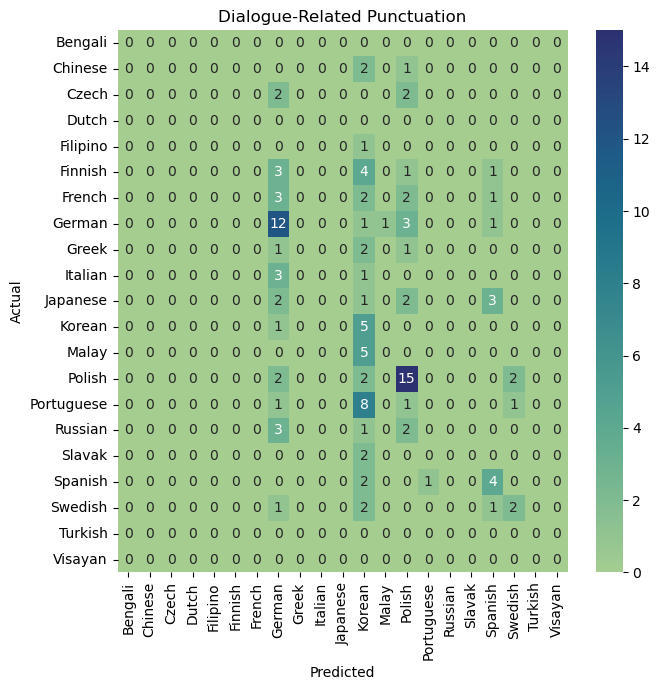

In [87]:
# Step 1: Select feature (punct) columns
feature_cols = [col for col in df_punct.columns if col.startswith('quot_')]

# Step 2: Extract features and labels
X = df_punct[feature_cols]
y = df_punct['L1']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

model = mnb()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(accuracy_score(y_test, y_pred))
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

# Plot it
plt.figure(figsize=(7, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='crest',
            xticklabels=model.classes_,
            yticklabels=model.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Dialogue-Related Punctuation')
plt.tight_layout()
plt.show()

0.2926829268292683


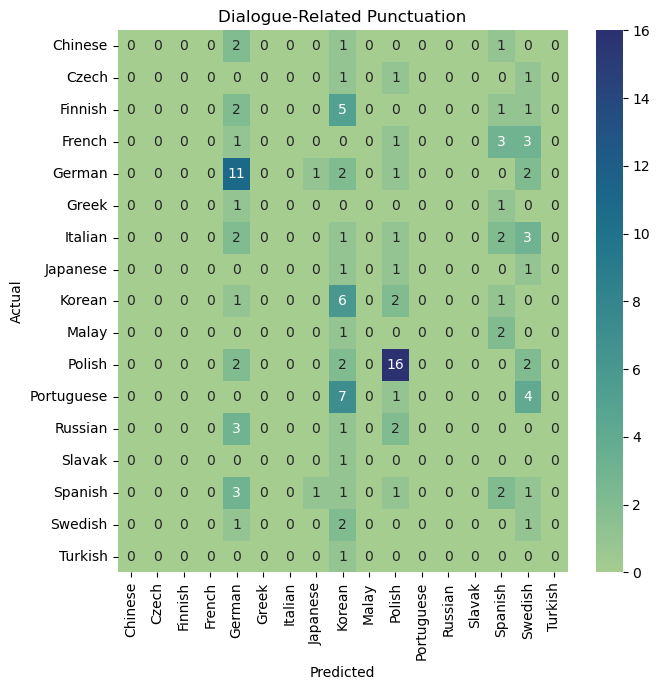

In [98]:
# Step 1: Select feature (punct) columns
df_punct = df_punct[~df_punct['L1'].isin(drop_langs)]
feature_cols = [col for col in df_punct.columns if col.startswith('quot_')]

# Step 2: Extract features and labels
X = df_punct[feature_cols]
y = df_punct['L1']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

model = mnb()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(accuracy_score(y_test, y_pred))
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

# Plot it
plt.figure(figsize=(7, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='crest',
            xticklabels=model.classes_,
            yticklabels=model.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Dialogue-Related Punctuation')
plt.tight_layout()
plt.show()

In [51]:
df_feats = pickle.load(open('df_feats.pkl', 'rb'))

In [52]:
drop_langs = ['Bengali', 'Vietnamese', 'Arabic', 'Catalan', 'Visayan', 'Bulgarian', 'Filipino', 'Dutch']
df_feats = df_feats[~df_feats['L1'].isin(drop_langs)]

0.13821138211382114


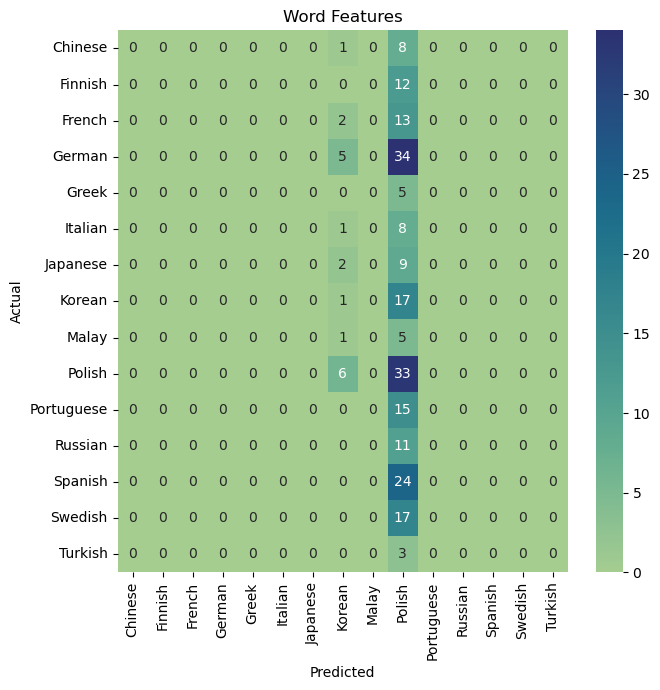

In [80]:
df_feats['word_feats_str'] = df_feats.feats_dict.map(lambda x : ' '.join([':'.join((z, x.get(z))) for z in x]))

df_feats = df_feats.sample(frac=1)

train = df_feats[:60]
test = df_feats[60:]

y_train = train['L1']
y_test = test['L1']

tfidfizer = TFIDFV(max_features=300, stop_words=None)
train_tfidf = tfidfizer.fit_transform(train.word_feats_str)
test_tfidf = tfidfizer.transform(test.word_feats_str)
nbclf = mnb()
nbclf.fit(train_tfidf, y_train)
y_pred = nbclf.predict(test_tfidf)
print(accuracy_score(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=nbclf.classes_)

# Plot it
plt.figure(figsize=(7, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='crest',
            xticklabels=nbclf.classes_,
            yticklabels=nbclf.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Word Features')
plt.tight_layout()
plt.show()

In [54]:
df_feats['word_feats_list'] = df_feats.feats_dict.map(lambda x : [':'.join((z, x.get(z))) for z in x])

In [64]:
df_feats['L1'].value_counts()

L1
Polish        49
German        44
Spanish       29
Korean        25
Portuguese    19
Swedish       19
French        19
Finnish       17
Japanese      15
Russian       14
Italian       13
Chinese       11
Czech          9
Malay          8
Greek          7
Turkish        4
Slavak         4
Name: count, dtype: int64

In [77]:
import random
colors = ['#990000', '#7A0000', '#E00000', '#520000', '#8F0000']
def custom_color_func(word, font_size, position, orientation, random_state=None, **kwargs):
    return random.choice(colors)

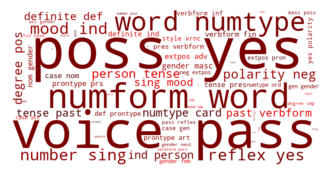

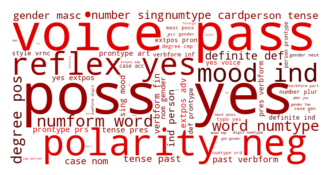

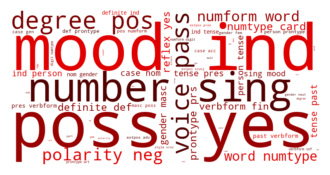

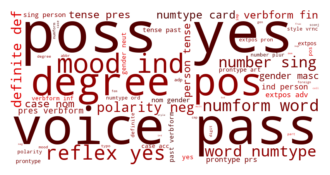

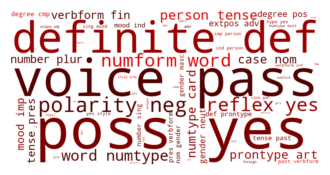

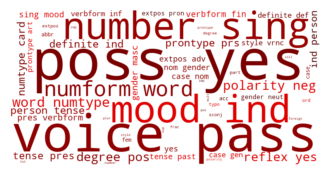

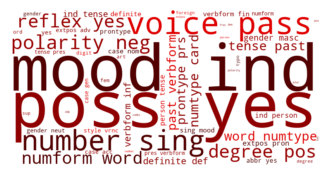

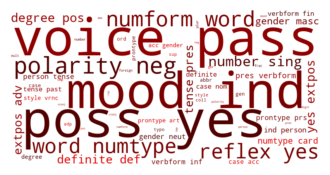

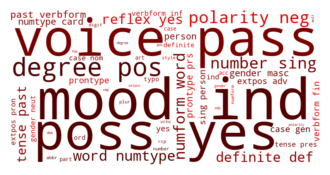

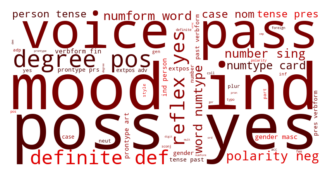

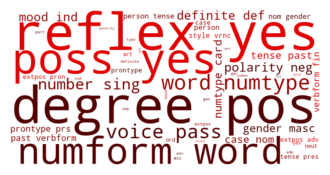

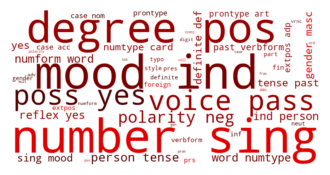

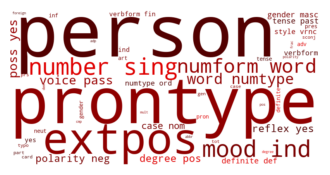

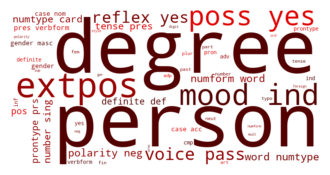

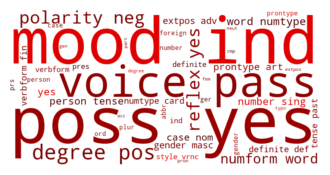

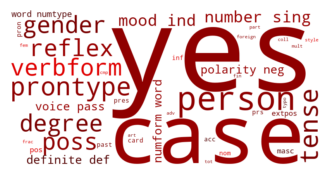

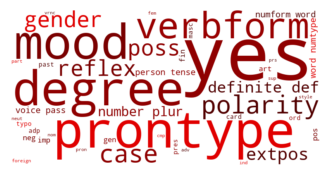

In [78]:
Polish = ' '.join(flatten([[x for x in y] for y in df_feats[df_feats['L1']=='Polish']['word_feats_list']]))
German = ' '.join(flatten([[x for x in y] for y in df_feats[df_feats['L1']=='German']['word_feats_list']]))
Spanish = ' '.join(flatten([[x for x in y] for y in df_feats[df_feats['L1']=='Spanish']['word_feats_list']]))
Korean = ' '.join(flatten([[x for x in y] for y in df_feats[df_feats['L1']=='Korean']['word_feats_list']]))
Portuguese = ' '.join(flatten([[x for x in y] for y in df_feats[df_feats['L1']=='Portuguese']['word_feats_list']]))
Swedish = ' '.join(flatten([[x for x in y] for y in df_feats[df_feats['L1']=='Swedish']['word_feats_list']]))
French = ' '.join(flatten([[x for x in y] for y in df_feats[df_feats['L1']=='French']['word_feats_list']]))
Finnish = ' '.join(flatten([[x for x in y] for y in df_feats[df_feats['L1']=='Finnish']['word_feats_list']]))
Japanese = ' '.join(flatten([[x for x in y] for y in df_feats[df_feats['L1']=='Japanese']['word_feats_list']]))
Russian = ' '.join(flatten([[x for x in y] for y in df_feats[df_feats['L1']=='Russian']['word_feats_list']]))
Italian = ' '.join(flatten([[x for x in y] for y in df_feats[df_feats['L1']=='Italian']['word_feats_list']]))
Chinese = ' '.join(flatten([[x for x in y] for y in df_feats[df_feats['L1']=='Chinese']['word_feats_list']]))
Czech = ' '.join(flatten([[x for x in y] for y in df_feats[df_feats['L1']=='Czech']['word_feats_list']]))
Malay = ' '.join(flatten([[x for x in y] for y in df_feats[df_feats['L1']=='Malay']['word_feats_list']]))
Greek = ' '.join(flatten([[x for x in y] for y in df_feats[df_feats['L1']=='Greek']['word_feats_list']]))
Turkish = ' '.join(flatten([[x for x in y] for y in df_feats[df_feats['L1']=='Turkish']['word_feats_list']]))
Slavak = ' '.join(flatten([[x for x in y] for y in df_feats[df_feats['L1']=='Slavak']['word_feats_list']]))
langs = [Polish, German, Spanish, Korean, Portuguese, Swedish, French, Finnish, Japanese, Russian, Italian, Chinese, Czech, Malay, Greek, Turkish, Slavak]

for l in langs:
    wc = WordCloud(width=800, height=400, background_color='white', color_func=custom_color_func).generate(l)
    plt.figure(figsize=(4, 4))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis("off")
    plt.show()


In [97]:
print(set(Polish.split(' ')))

{'verbform:part', 'prontype:ind', 'gender:fem', 'polarity:neg', 'mood:ind', 'degree:cmp', 'prontype:art', 'degree:pos', 'typo:yes', 'gender:neut', 'number:sing', 'case:acc', 'number:plur', 'prontype:int', 'polarity:pos', 'prontype:dem', 'extpos:adv', 'extpos:sconj', 'extpos:cconj', 'gender:masc', 'person:3', 'numtype:frac', 'numform:word', 'extpos:adp', 'style:vrnc', 'voice:pass', 'definite:ind', 'case:nom', 'style:coll', 'prontype:prs', 'mood:imp', 'numtype:mult', 'abbr:yes', 'numtype:card', 'definite:def', 'verbform:ger', 'prontype:neg', 'numtype:ord', 'case:gen', 'foreign:yes', 'person:1', 'verbform:inf', 'poss:yes', 'numform:digit', 'tense:pres', 'reflex:yes', 'extpos:pron', 'degree:sup', 'prontype:tot', 'person:2', 'verbform:fin', 'tense:past'}


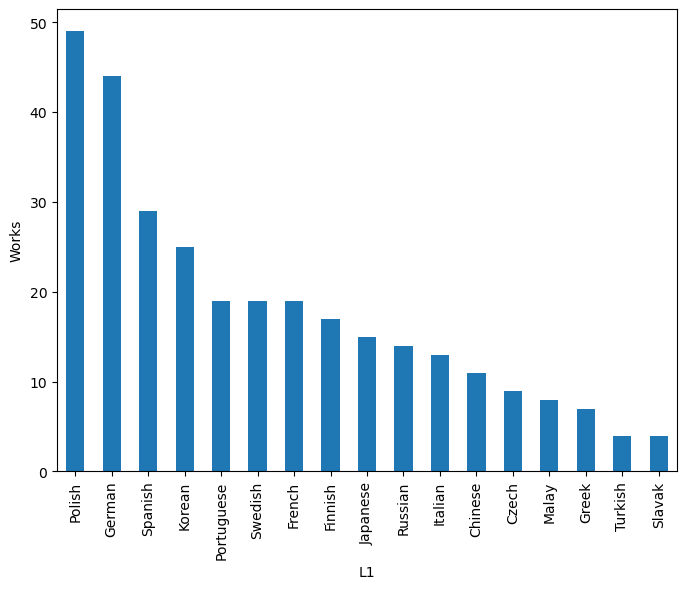

In [63]:
plt.figure(figsize=(8, 6))
df_feats['L1'].value_counts().plot(kind='bar')
plt.xlabel('L1')
plt.ylabel('Works')
plt.xticks(rotation=90)
plt.show()
